<a href="https://colab.research.google.com/github/kadentowle/DSC110/blob/main/ML_Model_Building_REAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#---------- IMPORTS ----------

import pandas as pd
from sklearn.linear_model import LinearRegression

In [4]:
#---------- LINEAR REGRESSION (CONTINUOUS OUTPUT) ----------

# Simple linear regression: predicting continuous values
X = pd.DataFrame({'age': [20, 30, 40, 50, 60]})
y = [110, 115, 120, 125, 130]

lr = LinearRegression()
lr.fit(X, y)

ages_to_predict = pd.DataFrame({'age': [10, 45, 80]})
predictions = lr.predict(ages_to_predict)

# print raw predictions
print(predictions)

# Printing with 2 decimals
for p in predictions:
     print(f"{p:.2f}")

[105.  122.5 140. ]
105.00
122.50
140.00


In [5]:
#---------- LINEAR REGRESSION (BINARY OUTCOME - NOT IDEAL) ----------

# Applying linear regression to binary 0/1 output

X = pd.DataFrame({'age': [20, 30, 40, 50, 60, 70]})
y = [0, 0, 0, 1, 1, 1]

lr = LinearRegression()
lr.fit(X, y)

ages_to_predict = pd.DataFrame({'age': [5, 45, 100]})
predictions = lr.predict(ages_to_predict)

for p in predictions:
     print(f"{p:.2f}")

-0.53
0.50
1.91


In [7]:
#---------- LOGISTIC REGRESSION (BINARY OUTPUT) ----------

# Predict probabilities between 0 and 1

from sklearn.linear_model import LogisticRegression
# import numpy as np

X = pd.DataFrame({'age': [20, 30, 40, 50, 60, 70]})
y = [0, 0, 0, 1, 1, 1]

lr = LogisticRegression()
lr.fit(X, y)

ages_to_predict = pd.DataFrame({'age': [5, 45, 100]})
probabilities = lr.predict_proba(ages_to_predict)

# Probability of class 1
for p in probabilities[:, 1]:
     print(f"{p:.2f}")

0.00
0.50
1.00


In [8]:
#---------- LOGISTIC REGRESSION (NON-LINEAR RELATIONSHIP) ----------

# When relationship is not linear

from sklearn.linear_model import LogisticRegression
import pandas as pd

X = pd.DataFrame({'age': [20, 30, 40, 50, 60, 70, 80]})
y = [0, 0, 1, 1, 1, 0, 0]

lr = LogisticRegression()
lr.fit(X, y)

ages_to_predict = pd.DataFrame({'age': [25, 50, 75]})
probabilities = lr.predict_proba(ages_to_predict)

for p in probabilities[:, 1]:
     print(f"{p:.2f}")

0.43
0.43
0.43


In [9]:
#---------- DECISION TREE ----------

#Tree-based classification

from sklearn.tree import DecisionTreeClassifier

X = pd.DataFrame({'age': [20, 30, 40, 50, 60, 70, 80]})
y = [0, 0, 1, 1, 1, 0, 0]

dt = DecisionTreeClassifier()
dt.fit(X, y)

ages_to_predict = pd.DataFrame({'age': [25, 50, 75]})
predictions = dt.predict(ages_to_predict)

for p in predictions:
    print(f"{p:.2f}")

0.00
1.00
0.00


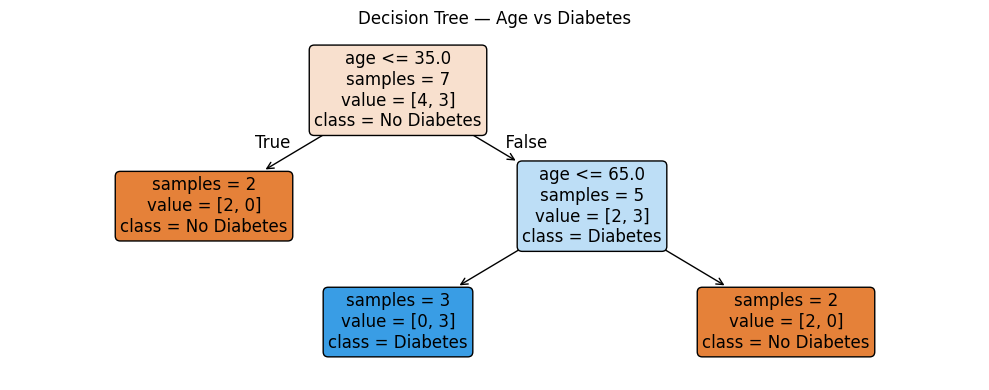

In [10]:
#---------- DECISION TREE VISUALIZATION ----------

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

plot_tree(dt,
          feature_names=['age'],
          class_names=['No Diabetes', 'Diabetes'],
          filled=True,
          rounded=True,
          fontsize=12,
          impurity=False,
          precision=0)

plt.title('Decision Tree — Age vs Diabetes')
plt.tight_layout()
plt.show()

#---------- PART 2: NHANES DATASET ----------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier

In [11]:
#---------- LOAD DATA ----------

X_train = pd.read_csv('https://raw.githubusercontent.com/osoliman/DSC110/refs/heads/main/Datasets/X_train.csv')
X_test  = pd.read_csv('https://raw.githubusercontent.com/osoliman/DSC110/refs/heads/main/Datasets/X_test.csv')
y_train = pd.read_csv('https://raw.githubusercontent.com/osoliman/DSC110/refs/heads/main/Datasets/y_train.csv')
y_test  = pd.read_csv('https://raw.githubusercontent.com/osoliman/DSC110/refs/heads/main/Datasets/y_test.csv')

#Convert y to 1D series
y_train = y_train.squeeze()
y_test  = y_test.squeeze()

#---------- VERIFY DATA SHAPES ----------

files = ['X_train', 'X_test', 'y_train', 'y_test']

for file_name in files:
    df = globals()[file_name]
    print(df.shape)

(6018, 15)
(1505, 15)
(6018,)
(1505,)
